# 📊 Unemployment Analysis with Python

## Oasis Infobyte Data Science Internship

### Task 2

**Author:** Sahil Chauhan

---

# Objective

The objective of this project is to analyze unemployment trends using Python. We will clean the dataset, perform exploratory data analysis (EDA), visualize unemployment patterns, and identify important insights from the data.

---

# Dataset

Dataset Source: Unemployment Rate in India

The dataset contains unemployment statistics collected from different states and regions of India. It includes unemployment rate, employment estimates, labour participation rate, date, and region information.

#  Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load Dataset
df = pd.read_csv('Datasets/Unemployment in India.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
# Dataset information
print("Dataset shape:",df.shape)

print("\ncolumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("Data Set Information:")
df.info()

Dataset shape: (768, 7)

columns:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

Data types:
Region                                          str
 Date                                           str
 Frequency                                      str
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                            str
dtype: object
Data Set Information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null   

In [5]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [6]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [7]:
print("duplicate rows:",df.duplicated().sum())

duplicate rows: 27


In [8]:
# dispaly all columns name
print("All columns name:")
print(df.columns)

All columns name:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


In [9]:
# removes extra names from the columns
df.columns = df.columns.str.strip()
print("updated columns name:")
print(df.columns)

updated columns name:
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


In [10]:
# convert date into datetime format
df["Date"] = pd.to_datetime(df["Date"],dayfirst=True)
print(df["Date"].head())

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[us]


# Checking Missing Values

## Objective

Missing values are empty or unavailable data points in a dataset.

Before analyzing data, it is important to identify missing values because they can affect the accuracy of analysis and machine learning models.

In this step, we will check the number of missing values in each column.

In [11]:
# checking missing values
missing_values = df.isnull().sum()
print("Missing values in each columns:")
print(missing_values)

Missing values in each columns:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [12]:
df = df.dropna()
print("Dataset shape after droping missing values:",df.shape)

Dataset shape after droping missing values: (740, 7)


# Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) is used to understand the dataset through visualizations and statistical summaries.

The main objectives are:

- Analyze unemployment trends.
- Compare unemployment rates across different states.
- Study employment distribution.
- Understand labour participation.
- Identify patterns and outliers.

# Visualization 1: Distribution of Unemployment Rate

# Objective

This histogram shows how unemployment rates are distributed across the dataset.

It helps identify:

- Most common unemployment rate
- Spread of values
- Skewness
- Outliers

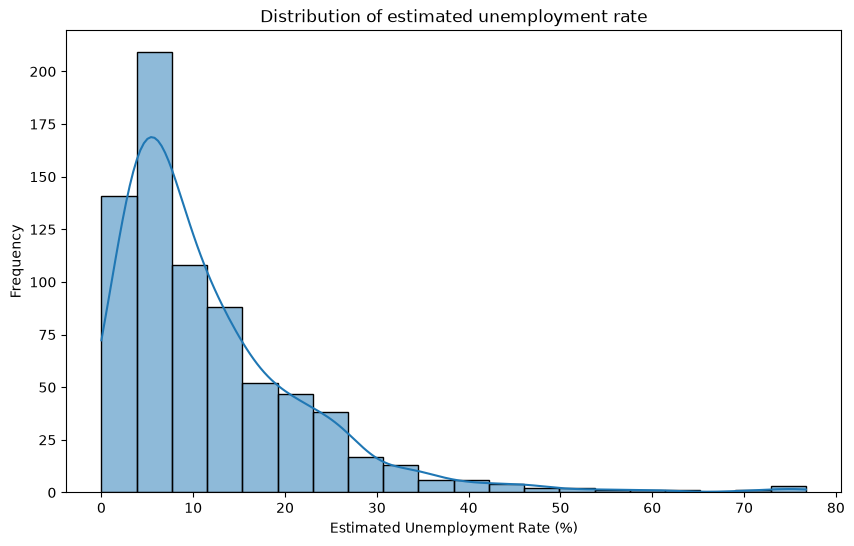

In [13]:
# Distribution of unemployment rate
plt.figure(figsize=(10,6))
sns.histplot(df["Estimated Unemployment Rate (%)"],
             bins=20,
             kde=True)
plt.title("Distribution of estimated unemployment rate")
plt.xlabel("Estimated Unemployment Rate (%)")
plt.ylabel("Frequency")

plt.show()

# Visualization 2: Average Unemployment Rate by Area

# Objective

This visualization compares the average unemployment rate between Urban and Rural areas.

It helps us understand whether unemployment is generally higher in urban regions or rural regions.

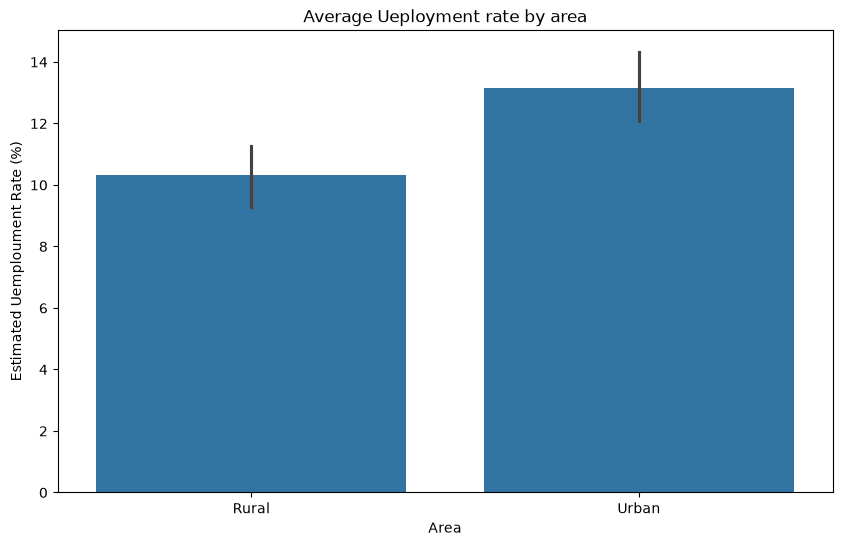

In [14]:
# Average unemployment rate by area
plt.figure(figsize=(10,6))

sns.barplot(data=df,
            x="Area",
            y="Estimated Unemployment Rate (%)",
            estimator="mean")

plt.title("Average Ueployment rate by area")
plt.xlabel("Area")
plt.ylabel("Estimated Uemploument Rate (%)")
plt.show()

# Visualization 3: Top 10 States with Highest Average Unemployment Rate

# Objective

This visualization identifies the top 10 states having the highest average unemployment rate.

It helps us determine which states experience the most unemployment and allows comparison among different regions.

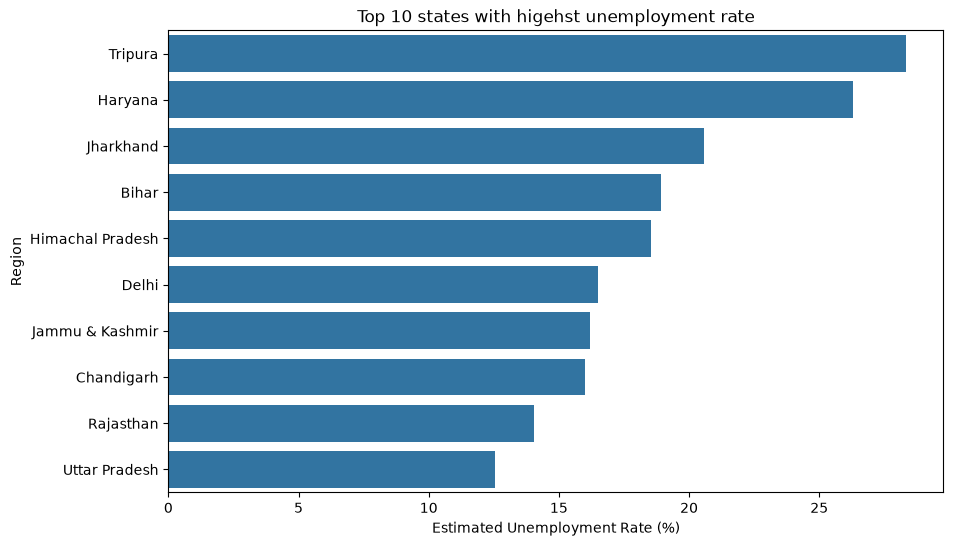

In [15]:
# top 10 states with highest unemployment rate
state_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(10,6))
sns.barplot(x=state_unemployment.values,
            y=state_unemployment.index)

plt.title("Top 10 states with higehst unemployment rate")
plt.xlabel("Estimated Unemployment Rate (%)")
plt.ylabel("Region")
plt.show()



# Visualization 4: Employment Distribution by Area

# Objective

This visualization compares the estimated employment between Urban and Rural areas.

It helps us understand which area has a higher average number of employed people.

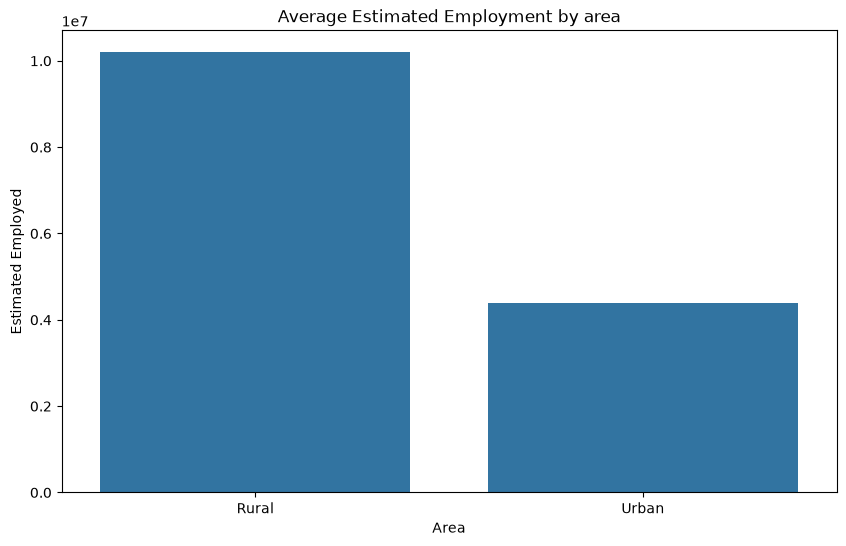

In [16]:
# Average Estimated employed by area
employment_area = (df.groupby("Area")["Estimated Employed"]
                   .mean()
                   .reset_index()
                   )

plt.figure(figsize=(10,6))
sns.barplot(data=employment_area,
            x="Area",
            y="Estimated Employed")

plt.title("Average Estimated Employment by area")
plt.xlabel("Area")
plt.ylabel("Estimated Employed")
plt.show()

# Visualization 5: Distribution of Labour Participation Rate

# Objective

This histogram shows the distribution of the Estimated Labour Participation Rate (%).

It helps us understand how labour participation values are spread across the dataset.

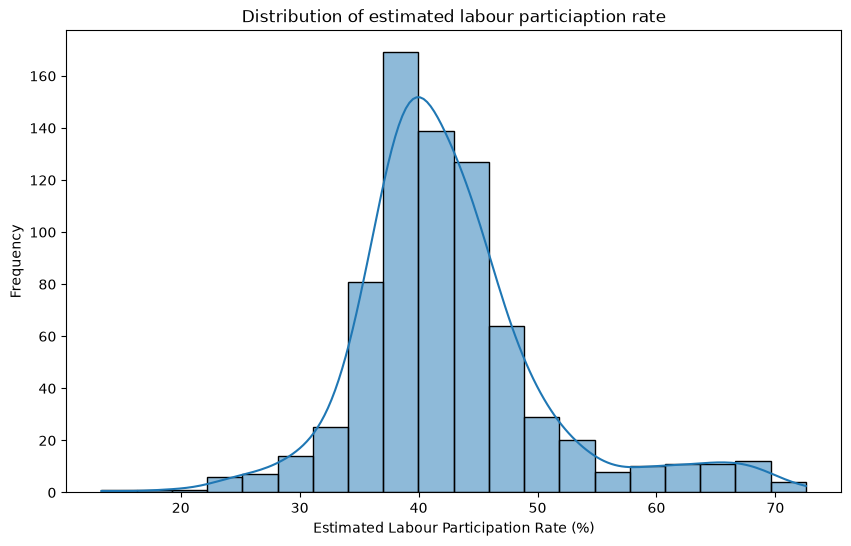

In [17]:
# labour participation rate distribution
plt.figure(figsize=(10,6))

sns.histplot(df["Estimated Labour Participation Rate (%)"],
             bins=20,
             kde=True)

plt.title("Distribution of estimated labour particiaption rate")
plt.xlabel("Estimated Labour Participation Rate (%)")
plt.ylabel("Frequency")

plt.show()

# Visualization 6: Correlation Heatmap

# Objective

A correlation heatmap helps identify the relationship between numerical variables in the dataset.

It shows whether two variables move together (positive correlation), move in opposite directions (negative correlation), or have little to no relationship.

This helps understand the dataset before making decisions or building machine learning models.

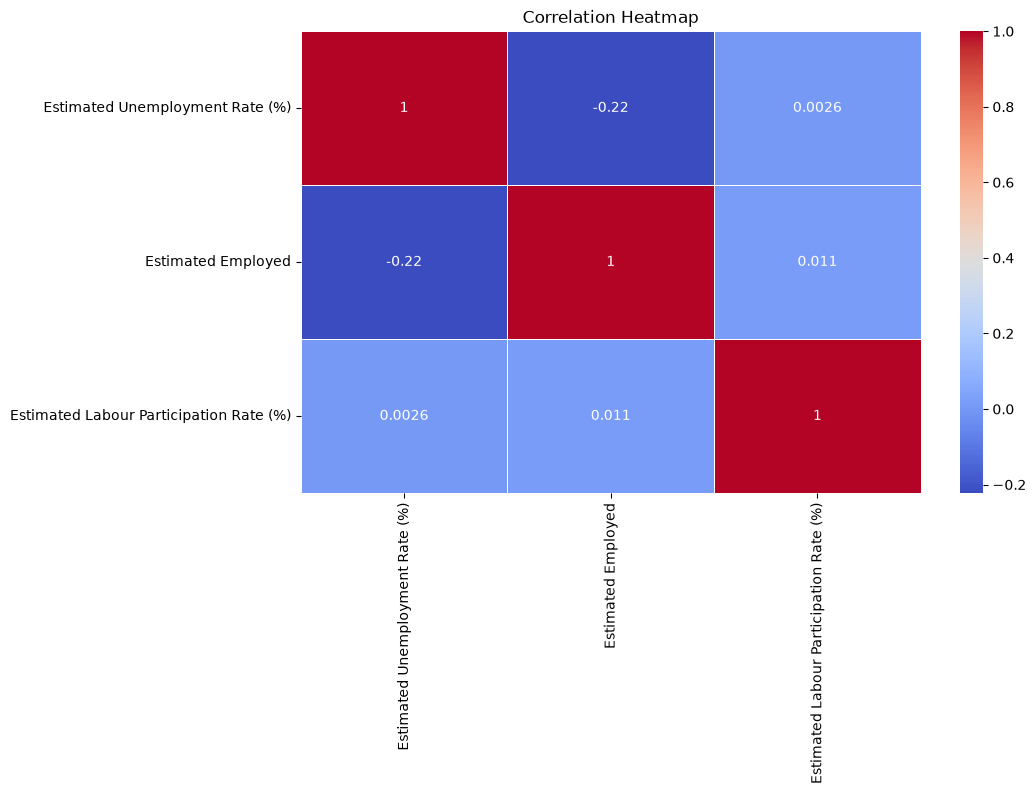

In [18]:
# select only numerical values
numerical_df = df.select_dtypes(include=['number'])

# create heatmap
plt.figure(figsize=(10,6))

sns.heatmap(numerical_df.corr(),
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

# Visualization 7: Monthly Unemployment Trend

# Objective

This visualization shows how the unemployment rate changes over time.

It helps identify trends, seasonal variations, and periods where unemployment increased or decreased.

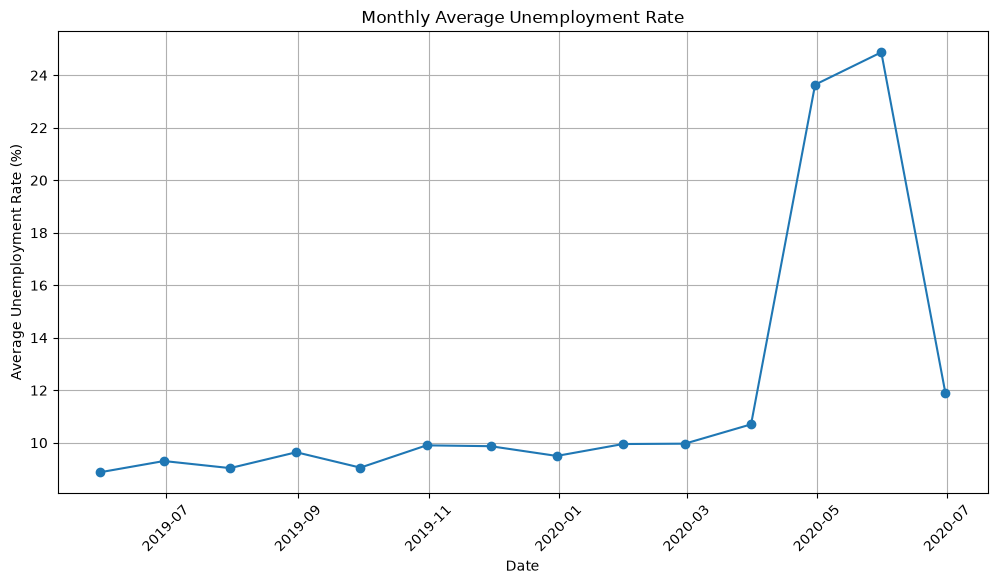

In [24]:
# Monthly Average Unemployment Rate

monthly_trend = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_trend["Date"],
    monthly_trend["Estimated Unemployment Rate (%)"],
    marker="o"
)

plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

# Visualization 8: Box Plot of Unemployment Rate

# Objective

This box plot helps identify the spread of unemployment rates and detect any outliers in the dataset.

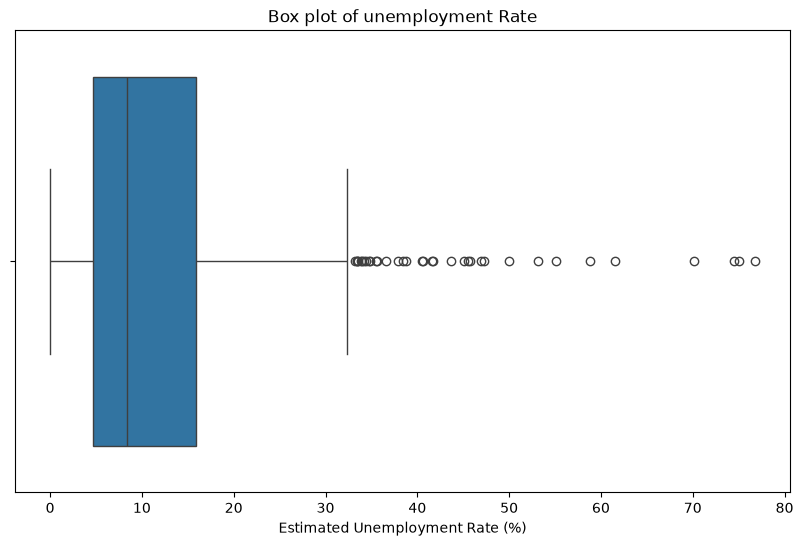

In [26]:
# Box Plot
plt.figure(figsize=(10,6))

sns.boxplot(x=df["Estimated Unemployment Rate (%)"])
plt.title("Box plot of unemployment Rate")
plt.show()


# Key Insights

- The dataset contains unemployment information for different states of India.
- Some states have higher unemployment rates than others.
- Urban and Rural areas show differences in unemployment.
- The unemployment rate changes over time.
- The heatmap shows relationships between numerical variables.
- Outliers are present in the unemployment rate.

# Conclusion

This project analyzed unemployment data using Python.

The dataset was cleaned, explored, and visualized using different charts.

Exploratory Data Analysis helped understand unemployment trends, employment distribution, labour participation, and relationships between variables.

This project improved my understanding of data analysis, visualization, and Python libraries such as Pandas, Matplotlib, and Seaborn.